<a href="https://colab.research.google.com/github/Maheen04/BME450-project/blob/main/BME450_CNN_LSTM_final_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Model
Uses a 1D Residual CNN to classify EEG signals as seizure or non-seizure.

Source data: https://archive.ics.uci.edu/dataset/1134/beed:+bangalore+eeg+epilepsy+dataset

Source for code architecture: https://pubmed.ncbi.nlm.nih.gov/30617320/ (introduces 1D Residual CNN)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, GlobalAveragePooling1D,
    Dense, Dropout, BatchNormalization, Add, Activation
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU: []


## Loading the dataset

In [ ]:
url = "https://raw.githubusercontent.com/myrakhare/Dataset_450/refs/heads/main/BEED_Data.csv" #CSV uploaded on github from UCI BEED Dataset
df = pd.read_csv(url)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

print('Dataset shape:', df.shape)
print('Label counts:')
print(df['y'].value_counts().sort_index())

Dataset shape: (8000, 17)
Label counts:
y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64


## Exploring the data

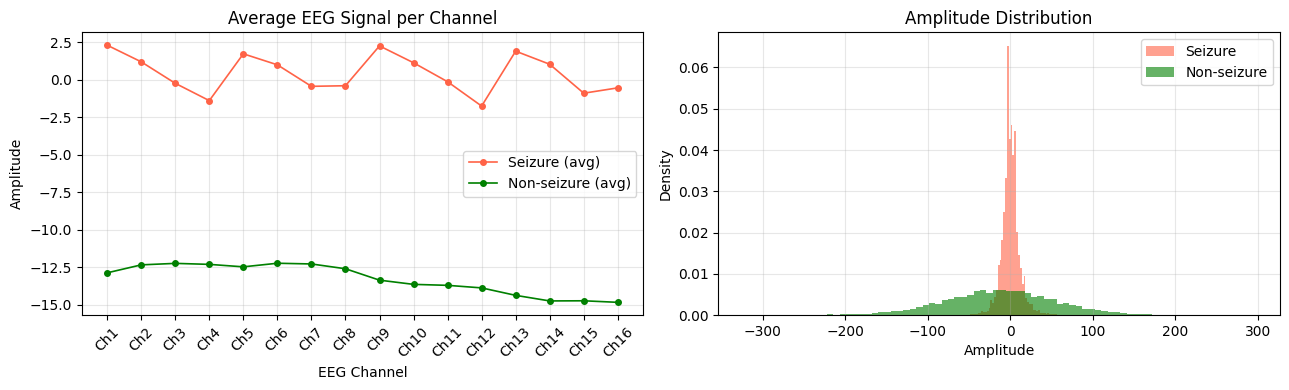

In [ ]:
# Average signal per channel for seizure vs nonseizure
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

seizure_mean    = df[df['y'] > 0].iloc[:, :-1].mean().values
nonseizure_mean = df[df['y'] == 0].iloc[:, :-1].mean().values
channels        = [f'Ch{i+1}' for i in range(len(seizure_mean))]

axes[0].plot(seizure_mean,    color='tomato',    label='Seizure (avg)',     linewidth=1.2, marker='o', markersize=4)
axes[0].plot(nonseizure_mean, color='green', label='Non-seizure (avg)', linewidth=1.2, marker='o', markersize=4)
axes[0].set_xticks(range(len(channels)))
axes[0].set_xticklabels(channels, rotation=45)
axes[0].set_title('Average EEG Signal per Channel')
axes[0].set_xlabel('EEG Channel')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(alpha=0.3)

seizure_vals    = df[df['y'] > 0].iloc[:, :-1].values.flatten()
nonseizure_vals = df[df['y'] == 0].iloc[:, :-1].values.flatten()
axes[1].hist(seizure_vals,    bins=80, alpha=0.6, color='tomato',    label='Seizure',     density=True)
axes[1].hist(nonseizure_vals, bins=80, alpha=0.6, color='green', label='Non-seizure', density=True)
axes[1].set_title('Amplitude Distribution')
axes[1].set_xlabel('Amplitude')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Preprocessing

In [ ]:
X     = df.drop(columns='y').values       # (8000, 16)
y_raw = df['y'].values

# Binarize: 0 = healthy (no seizure), 1/2/3 = seizure
y_bin = (y_raw > 0).astype(int)
y_cat = to_categorical(y_bin, num_classes=2)

# Z-score normalize then reshape for Conv1D input
# Split on RAW data first, then scale
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y_cat, test_size=0.30,
                                             stratify=y_bin, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50,
                                             random_state=42)

# Fit scaler on training set only, then apply to val and test
scaler = StandardScaler()
X_tr  = scaler.fit_transform(X_tr).reshape(-1, 16, 1)
X_val = scaler.transform(X_val).reshape(-1, 16, 1)
X_te  = scaler.transform(X_te).reshape(-1, 16, 1)

print(f'Train : {X_tr.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_te.shape}')

print(f'Train : {X_tr.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_te.shape}')

Train : (5600, 16, 1)
Val   : (1200, 16, 1)
Test  : (1200, 16, 1)
Train : (5600, 16, 1)
Val   : (1200, 16, 1)
Test  : (1200, 16, 1)


## Model architecture

Notes: The CNN learns across the 16 EEG electrode channels (brain regions) rather than across time. Residual blocks with kernel size 3 are used since the input sequence is short (16 channels). collapses the channel dimension into a fixed-size vector.

In [ ]:
def res_block(x, n_filters, kernel_size=3, downsample=False):
    stride = 2 if downsample else 1
    skip = x

    x = Conv1D(n_filters, kernel_size, strides=stride, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.2)(x)
    x = Conv1D(n_filters, kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)

    if downsample or skip.shape[-1] != n_filters:
        skip = Conv1D(n_filters, 1, strides=stride, padding='same', use_bias=False)(skip)
        skip = BatchNormalization()(skip)

    return Activation('relu')(Add()([x, skip]))

FEATURE_DIM = 128
TIMESTEPS   = 16    # BEED dataset, 16 EEG channels per sample

inp = Input(shape=(TIMESTEPS, 1), name='cnn_input')

# Entry conv w small kernel since sequence is only 16 long
x = Conv1D(64, kernel_size=3, padding='same', use_bias=False)(inp)
x = BatchNormalization()(x)
x = Activation('relu')(x)

# Fewer or shallower blocks no downsampling on a 16length sequence
x = res_block(x, 64)
x = res_block(x, 128)
x = res_block(x, 256)

x = GlobalAveragePooling1D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.25)(x)

cnn_features = Dense(FEATURE_DIM, activation='relu', name='cnn_features')(x)
out = Dense(2, activation='softmax', name='cnn_output')(cnn_features)

cnn_model = Model(inp, out, name='CNN_Branch')
cnn_model.summary()

Model: "CNN_Branch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_input           │ (None, 16, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 16, 64)    │        192 │ cnn_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 16, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 16, 64)    │     12,288 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 16, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 64)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 16, 64)    │     12,288 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 16, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 16, 128)   │     24,576 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 128)   │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 16, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16, 128)   │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 16, 128)   │     49,152 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 16, 128)   │      8,192 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 128)   │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 637,250 (2.43 MB)

 Trainable params: 634,562 (2.42 MB)

 Non-trainable params: 2,688 (10.50 KB)

## Training

In [ ]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history = cnn_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 31s 144ms/step - accuracy: 0.9850 - loss: 0.0401 - val_accuracy: 0.9650 - val_loss: 0.0987 - learning_rate: 0.0010
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.9971 - loss: 0.0102 - val_accuracy: 0.9817 - val_loss: 0.0511 - learning_rate: 0.0010
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.9986 - loss: 0.0052 - val_accuracy: 0.9875 - val_loss: 0.0375 - learning_rate: 0.0010
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - accuracy: 0.9980 - loss: 0.0076 - val_accuracy: 0.9983 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - accuracy: 0.9968 - loss: 0.0081 - val_accuracy: 0.9992 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 151ms/step - accuracy: 0.9980 - loss: 0.0055 - val_accuracy: 0.9992 - val_loss: 9.6952e-04 - learning_rate: 0.0010
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 150ms/step - accuracy: 0.9987 - loss

## Evaluation step

In [ ]:
loss, acc = cnn_model.evaluate(X_te, y_te, verbose=0)
print(f'Test Accuracy : {acc:.4f}')
print(f'Test Loss     : {loss:.4f}')

y_pred = np.argmax(cnn_model.predict(X_te), axis=1)
y_true = np.argmax(y_te, axis=1)

class_names = ['Non-seizure', 'Seizure']
print('\n', classification_report(y_true, y_pred, target_names=class_names))

Test Accuracy : 0.9983
Test Loss     : 0.0027
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

               precision    recall  f1-score   support

 Non-seizure       1.00      0.99      1.00       299
     Seizure       1.00      1.00      1.00       901

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



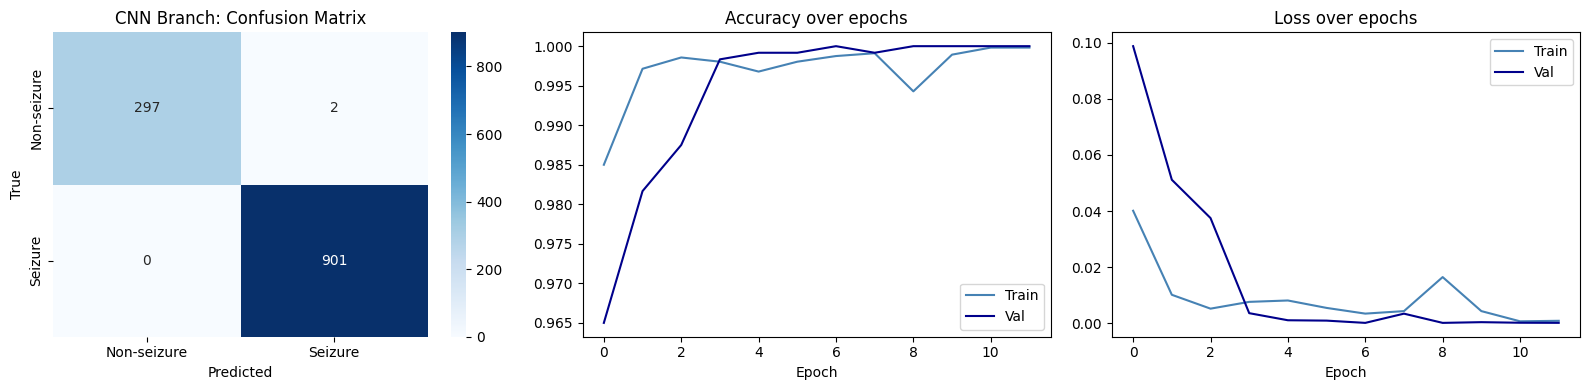

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('CNN Branch: Confusion Matrix')

axes[1].plot(history.history['accuracy'], label='Train', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val', color='darkblue')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['loss'], label='Train', color='steelblue')
axes[2].plot(history.history['val_loss'], label='Val', color='darkblue')
axes[2].set_title('Loss over epochs')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

## Saving the model

In [ ]:
cnn_model.save('cnn_branch.keras')

cnn_feature_extractor = Model(
    inputs=cnn_model.input,
    outputs=cnn_model.get_layer('cnn_features').output,
    name='CNN_Feature_Extractor'
)
cnn_feature_extractor.save('cnn_feature_extractor.keras')

print('Saved: cnn_branch.keras')
print('Saved: cnn_feature_extractor.keras')
print('Fusion output shape:', cnn_feature_extractor.output_shape)

Saved: cnn_branch.keras
Saved: cnn_feature_extractor.keras
Fusion output shape: (None, 128)


# LSTM Model

In [ ]:
# LSTM BRANCH  — trained on BEED (same splits as CNN)
# ─────────────────────────────────────────────────────────────────────────────
from tensorflow.keras.layers import LSTM, AveragePooling1D

FEATURE_DIM = 128   # must match CNN branch

In [ ]:
# ── Build ─────────────────────────────────────────────────────────────────────
lstm_inp = Input(shape=(16, 1), name='lstm_input')

# No AveragePooling1D — can't pool a 16-step sequence
# Smaller LSTM units than the 178-timestep version (less temporal info here)
x = LSTM(64, return_sequences=True,  activation='relu', name='lstm_1')(lstm_inp)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = LSTM(64, return_sequences=False, activation='relu', name='lstm_2')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.25)(x)

# ── Fusion handoff — do NOT rename this layer ─────────────────────────────────
lstm_features = Dense(FEATURE_DIM, activation='relu', name='lstm_features')(x)
lstm_out      = Dense(2, activation='softmax', name='lstm_output')(lstm_features)

lstm_model = Model(lstm_inp, lstm_out, name='LSTM_Branch')
lstm_model.summary()

Model: "LSTM_Branch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_input (InputLayer)         │ (None, 16, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_features (Dense)           │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_output (Dense)             │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,226 (391.51 KB)

 Trainable params: 99,970 (390.51 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
# ── Compile ───────────────────────────────────────────────────────────────────
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

In [13]:
# ── Train — reuses X_tr/X_val already in memory from CNN cell ─────────────────
lstm_history = lstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9621 - loss: 0.1023 - val_accuracy: 0.7525 - val_loss: 0.4886 - learning_rate: 0.0010
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9889 - loss: 0.0352 - val_accuracy: 0.7500 - val_loss: 0.8913 - learning_rate: 0.0010
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9920 - loss: 0.0246 - val_accuracy: 0.7733 - val_loss: 0.7021 - learning_rate: 0.0010
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9932 - loss: 0.0198 - val_accuracy: 0.7592 - val_loss: 0.7554 - learning_rate: 0.0010
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9975 - loss: 0.0089 - val_accuracy: 0.8867 - val_loss: 0.3679 - learning_rate: 5.0000e-04
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9984 - loss: 0.0060 - val_accuracy: 0.9475 - val_loss: 0.1574 - learning_rate: 5.0000e-04
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9982 - loss: 0.0046 -

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
              precision    recall  f1-score   support

 Non-seizure       1.00      0.99      1.00       299
     Seizure       1.00      1.00      1.00       901

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



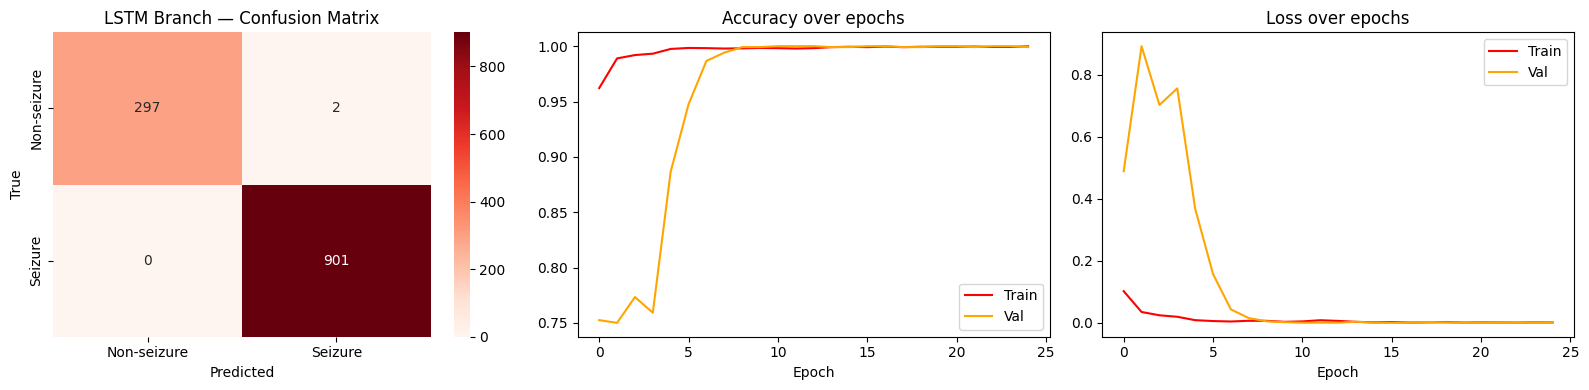

In [14]:
# Run this if you hit the lstm_y_pred NameError
lstm_y_pred = np.argmax(lstm_model.predict(X_te), axis=1)
y_true      = np.argmax(y_te, axis=1)
class_names = ['Non-seizure', 'Seizure']

print(classification_report(y_true, lstm_y_pred, target_names=class_names))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm = confusion_matrix(y_true, lstm_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('LSTM Branch — Confusion Matrix')

axes[1].plot(lstm_history.history['accuracy'],     label='Train', color='red')
axes[1].plot(lstm_history.history['val_accuracy'], label='Val', color='orange')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(lstm_history.history['loss'],     label='Train',color='red')
axes[2].plot(lstm_history.history['val_loss'], label='Val', color='orange')
axes[2].set_title('Loss over epochs')
axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── Save ──────────────────────────────────────────────────────────────────────
lstm_model.save('lstm_branch.keras')

lstm_feature_extractor = Model(
    inputs=lstm_model.input,
    outputs=lstm_model.get_layer('lstm_features').output,
    name='LSTM_Feature_Extractor'
)
lstm_feature_extractor.save('lstm_feature_extractor.keras')

print('Saved: lstm_branch.keras')
print('Saved: lstm_feature_extractor.keras')
print('Fusion vector shape:', lstm_feature_extractor.output_shape)  # (None, 128)

Saved: lstm_branch.keras
Saved: lstm_feature_extractor.keras
Fusion vector shape: (None, 128)


# Fusion Section

## BEED Dataset

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FUSION — IN-DISTRIBUTION TEST  (BEED, same dataset as branches)
# ─────────────────────────────────────────────────────────────────────────────
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import concatenate
from tensorflow.keras.metrics import AUC, Precision, Recall
from sklearn.metrics import roc_auc_score


In [ ]:
# ── Load frozen extractors ────────────────────────────────────────────────────
lstm_ext = load_model('lstm_feature_extractor.keras')
cnn_ext  = load_model('cnn_feature_extractor.keras')

lstm_ext.trainable = False
cnn_ext.trainable  = False

In [ ]:
# ── Build fusion head (same architecture used later for cross-dataset) ─────────
shared_input  = Input(shape=(16, 1), name='shared_input')
lstm_vec      = lstm_ext(shared_input)
cnn_vec       = cnn_ext(shared_input)
combined      = concatenate([lstm_vec, cnn_vec])        # (batch, 256)
x = Dense(128, activation='relu')(combined)
x = Dropout(0.3)(x)
x = Dense(64,  activation='relu')(x)
x = Dropout(0.2)(x)
beed_fusion_output = Dense(2, activation='softmax', name='fusion_output')(x)

beed_fusion_model = Model(
    inputs=shared_input,
    outputs=beed_fusion_output,
    name='CNN_LSTM_Fusion_BEED'
)

beed_fusion_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        AUC(name='auc'),
        Precision(name='precision'),
        Recall(name='recall'),
    ]
)

In [ ]:
# ── Train on BEED — reuses X_tr / X_val already in memory ────────────────────
beed_fusion_history = beed_fusion_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[
        EarlyStopping(monitor='val_auc', patience=8, mode='max',
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-6),
    ]
)

In [ ]:
# ── Evaluate on BEED test set ─────────────────────────────────────────────────
beed_results = beed_fusion_model.evaluate(X_te, y_te, verbose=0)
print('\n── Fusion (BEED) Test Metrics ──')
for name, val in zip(beed_fusion_model.metrics_names, beed_results):
    print(f'  {name:<12}: {val:.4f}')

beed_fusion_prob = beed_fusion_model.predict(X_te)
beed_fusion_pred = np.argmax(beed_fusion_prob, axis=1)
y_true           = np.argmax(y_te, axis=1)
class_names      = ['Non-seizure', 'Seizure']

print('\n── Classification Report ──')
print(classification_report(y_true, beed_fusion_pred, target_names=class_names))
print(f'ROC-AUC: {roc_auc_score(y_true, beed_fusion_prob[:, 1]):.4f}')

In [ ]:
# ── In-distribution branch vs fusion comparison ───────────────────────────────
cnn_prob_beed  = cnn_model.predict(X_te)
lstm_prob_beed = lstm_model.predict(X_te)

print('\n══ In-Distribution Comparison (BEED test set) ══')
print(f"  {'Model':<22} {'Accuracy':>10} {'ROC-AUC':>10}")
print(f"  {'-'*44}")
for label, prob in [
    ('CNN Branch',           cnn_prob_beed),
    ('LSTM Branch',          lstm_prob_beed),
    ('CNN-LSTM Fusion (BEED)', beed_fusion_prob),
]:
    pred = np.argmax(prob, axis=1)
    acc  = (pred == y_true).mean()
    auc  = roc_auc_score(y_true, prob[:, 1])
    print(f"  {label:<22} {acc:>10.4f} {auc:>10.4f}")

In [ ]:
# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm = confusion_matrix(y_true, beed_fusion_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='PuBu',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Fusion (BEED) — Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

axes[1].plot(beed_fusion_history.history['accuracy'],     label='Train', color='pink')
axes[1].plot(beed_fusion_history.history['val_accuracy'], label='Val', color='steelblue')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(beed_fusion_history.history['auc'],     label='Train', color='pink')
axes[2].plot(beed_fusion_history.history['val_auc'], label='Val', color='steelblue')
axes[2].set_title('AUC'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.suptitle('CNN–LSTM Fusion — In-Distribution (BEED)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── Save ──────────────────────────────────────────────────────────────────────
beed_fusion_model.save('cnn_lstm_fusion_beed.keras')
print('\nSaved: cnn_lstm_fusion_beed.keras')

## UCI ML Repository Dataset

In [19]:
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import concatenate
from tensorflow.keras.metrics import AUC, Precision, Recall
from sklearn.metrics import roc_auc_score
from tensorflow.keras.callbacks import CSVLogger

In [21]:
# ── Load frozen extractors ────────────────────────────────────────────────────
lstm_ext = load_model('lstm_feature_extractor.keras')
cnn_ext  = load_model('cnn_feature_extractor.keras')

lstm_ext.trainable = False
cnn_ext.trainable  = False

In [22]:
# ── Load Epileptic Seizure dataset ────────────────────────────────────────────
url2  = "https://raw.githubusercontent.com/Maheen04/BME450-project/main/Epileptic%20Seizure%20Recognition.csv"
df2   = pd.read_csv(url2)
df2   = df2.drop(df2.columns[0], axis=1)          # drop ID column
df2   = df2.select_dtypes(include=[np.number])     # guarantee all numeric

print('Fusion dataset shape:', df2.shape)          # should be (11500, 179)
print('Label counts:\n', df2['y'].value_counts().sort_index())

X2      = df2.drop(columns='y').values             # (11500, 178)
y2_raw  = df2['y'].values
y2_bin  = (y2_raw == 1).astype(int)               # class 1 = seizure, rest = non
y2_cat  = to_categorical(y2_bin, num_classes=2)

Fusion dataset shape: (11500, 179)
Label counts:
 y
1    2300
2    2300
3    2300
4    2300
5    2300
Name: count, dtype: int64


In [23]:
# ── Subsample 178 → 16 timesteps to match extractor input shape ───────────────
X2_scaled = StandardScaler().fit_transform(X2)
idx       = np.linspace(0, 177, 16, dtype=int)    # 16 evenly spaced indices
X2_16     = X2_scaled[:, idx].reshape(-1, 16, 1)  # (11500, 16, 1)

In [24]:
# ── 70 / 15 / 15 stratified split ────────────────────────────────────────────
X2_tr, X2_tmp, y2_tr, y2_tmp = train_test_split(
    X2_16, y2_cat, test_size=0.30, stratify=y2_bin, random_state=42)
X2_val, X2_te, y2_val, y2_te = train_test_split(
    X2_tmp, y2_tmp, test_size=0.50, random_state=42)

print(f'Fusion train : {X2_tr.shape}')
print(f'Fusion val   : {X2_val.shape}')
print(f'Fusion test  : {X2_te.shape}')

Fusion train : (8050, 16, 1)
Fusion val   : (1725, 16, 1)
Fusion test  : (1725, 16, 1)


In [25]:
# ── Build fusion head ─────────────────────────────────────────────────────────
# Single shared input — both extractors take the same (16, 1) tensor
shared_input = Input(shape=(16, 1), name='shared_input')

lstm_vec = lstm_ext(shared_input)                  # (batch, 128)
cnn_vec  = cnn_ext(shared_input)                   # (batch, 128)

combined = concatenate([lstm_vec, cnn_vec])         # (batch, 256)
x = Dense(128, activation='relu')(combined)
x = Dropout(0.3)(x)
x = Dense(64,  activation='relu')(x)
x = Dropout(0.2)(x)
fusion_output = Dense(2, activation='softmax', name='fusion_output')(x)

fusion_model = Model(
    inputs=shared_input,
    outputs=fusion_output,
    name='CNN_LSTM_Fusion'
)
fusion_model.summary()

Model: "CNN_LSTM_Fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ shared_input        │ (None, 16, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_Feature_Extra… │ (None, 128)       │     99,968 │ shared_input[0][… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNN_Feature_Extrac… │ (None, 128)       │    636,992 │ shared_input[0][… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ LSTM_Feature_Ext… │
│ (Concatenate)       │                   │            │ CNN_Feature_Extr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_output       │ (None, 2)         │        130 │ dropout_8[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 778,242 (2.97 MB)

 Trainable params: 41,282 (161.26 KB)

 Non-trainable params: 736,960 (2.81 MB)

In [26]:
# ── Compile ───────────────────────────────────────────────────────────────────
fusion_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        AUC(name='auc'),
        Precision(name='precision'),
        Recall(name='recall'),
    ]
)

In [27]:
# ── Train ─────────────────────────────────────────────────────────────────────
fusion_history = fusion_model.fit(
    X2_tr, y2_tr,
    validation_data=(X2_val, y2_val),
    epochs=50,
    batch_size=64,
    callbacks=[
        EarlyStopping(monitor='val_auc', patience=8, mode='max',
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-6),
        CSVLogger('fusion_training_log.csv'),
    ]
)

Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.9019 - auc: 0.9496 - loss: 0.3405 - precision: 0.9019 - recall: 0.9019 - val_accuracy: 0.9513 - val_auc: 0.9837 - val_loss: 0.1696 - val_precision: 0.9513 - val_recall: 0.9513 - learning_rate: 0.0010
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.9409 - auc: 0.9815 - loss: 0.1703 - precision: 0.9409 - recall: 0.9409 - val_accuracy: 0.9484 - val_auc: 0.9875 - val_loss: 0.1352 - val_precision: 0.9484 - val_recall: 0.9484 - learning_rate: 0.0010
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.9437 - auc: 0.9831 - loss: 0.1690 - precision: 0.9437 - recall: 0.9437 - val_accuracy: 0.9548 - val_auc: 0.9891 - val_loss: 0.1320 - val_precision: 0.9548 - val_recall: 0.9548 - learning_rate: 0.0010
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.9472 - auc: 0.9878 - loss: 0.1379 - precision: 0.9472 - recall: 0.9472 - val_accuracy: 0.9577 - val_auc: 0.9905 - val_loss: 0.1207 

In [28]:
# ── Evaluate ──────────────────────────────────────────────────────────────────
fusion_results = fusion_model.evaluate(X2_te, y2_te, verbose=0)
print('\n── Fusion Test Metrics ──')
for name, val in zip(fusion_model.metrics_names, fusion_results):
    print(f'  {name:<12}: {val:.4f}')

fusion_y_prob = fusion_model.predict(X2_te)
fusion_y_pred = np.argmax(fusion_y_prob, axis=1)
y2_true       = np.argmax(y2_te, axis=1)
class_names   = ['Non-seizure', 'Seizure']

print('\n── Classification Report ──')
print(classification_report(y2_true, fusion_y_pred, target_names=class_names))
print(f'ROC-AUC: {roc_auc_score(y2_true, fusion_y_prob[:, 1]):.4f}')


── Fusion Test Metrics ──
  loss        : 0.1083
  compile_metrics: 0.9548
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step

── Classification Report ──
              precision    recall  f1-score   support

 Non-seizure       0.96      0.99      0.97      1370
     Seizure       0.94      0.83      0.88       355

    accuracy                           0.95      1725
   macro avg       0.95      0.91      0.93      1725
weighted avg       0.95      0.95      0.95      1725

ROC-AUC: 0.9896


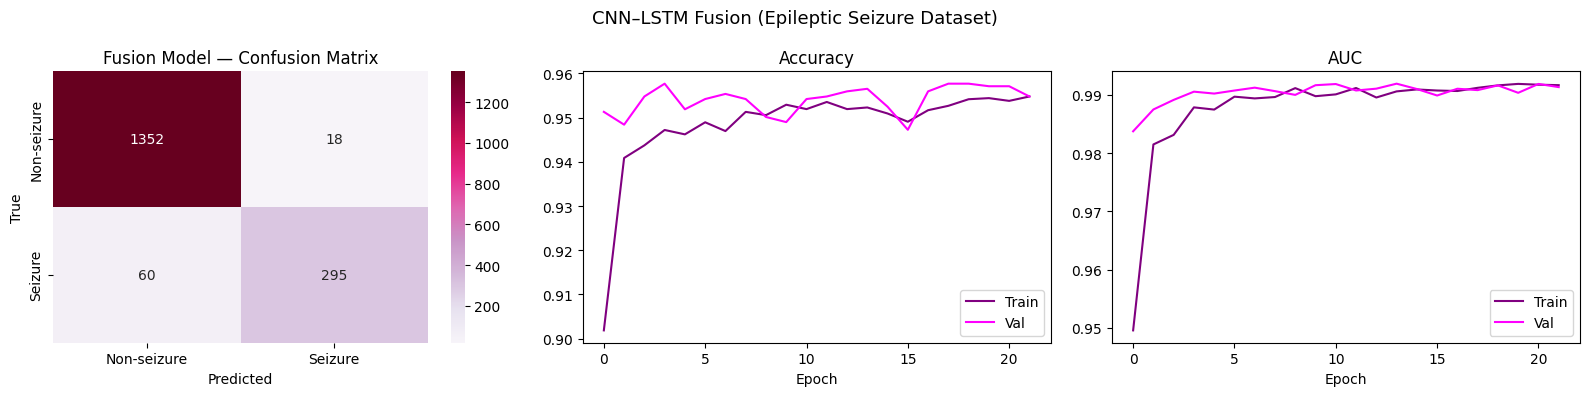

In [30]:
# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm = confusion_matrix(y2_true, fusion_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Fusion Model — Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

axes[1].plot(fusion_history.history['accuracy'],     label='Train', color = 'purple')
axes[1].plot(fusion_history.history['val_accuracy'], label='Val', color = 'magenta')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(fusion_history.history['auc'],     label='Train', color = 'purple')
axes[2].plot(fusion_history.history['val_auc'], label='Val', color = 'magenta')
axes[2].set_title('AUC'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.suptitle('CNN–LSTM Fusion (Epileptic Seizure Dataset)', fontsize=13)
plt.tight_layout()
plt.show()

In [31]:
# ── Branch vs Fusion summary ──────────────────────────────────────────────────
# Re-evaluate CNN and LSTM on the same fusion test set for fair comparison
cnn_ext_full  = load_model('cnn_branch.keras')
lstm_ext_full = load_model('lstm_branch.keras')

cnn_prob  = cnn_ext_full.predict(X2_te)
lstm_prob = lstm_ext_full.predict(X2_te)

print('\n══ Model Comparison (Epileptic Seizure test set) ══')
print(f"  {'Model':<20} {'Accuracy':>10} {'ROC-AUC':>10}")
print(f"  {'-'*42}")
for label, prob in [
    ('CNN Branch',      cnn_prob),
    ('LSTM Branch',     lstm_prob),
    ('CNN-LSTM Fusion', fusion_y_prob),
]:
    pred = np.argmax(prob, axis=1)
    acc  = (pred == y2_true).mean()
    auc  = roc_auc_score(y2_true, prob[:, 1])
    print(f"  {label:<20} {acc:>10.4f} {auc:>10.4f}")

54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step

══ Model Comparison (Epileptic Seizure test set) ══
  Model                  Accuracy    ROC-AUC
  ------------------------------------------
  CNN Branch               0.2330     0.6488
  LSTM Branch              0.2962     0.6664
  CNN-LSTM Fusion          0.9548     0.9896


In [32]:
# ── Save ──────────────────────────────────────────────────────────────────────
fusion_model.save('cnn_lstm_fusion.keras')
print('\nSaved: cnn_lstm_fusion.keras')


Saved: cnn_lstm_fusion.keras
